# Global Fireworks & Air Quality Analysis (2013–2026)

Every year, billions of people celebrate with fireworks. 
This dataset measures what that actually does to the atmosphere,
across 155 countries, 11 cultural celebrations, and 13 years of hourly data.

**Key findings:**
-  PM10 rises 26% on New Year's Eve globally at the grid-cell scale (ERA5/CAMS model data; local peaks near fireworks sites will be higher), but recovers within days, leaving no measurable trace in soil data.
-  SO₂ and NO₂ *fall* on New Year's Eve (−52% and −35%), because holiday traffic reductions outweigh pyrotechnic emissions, making PM10 a more reliable fireworks indicator than gas-phase measurements.
-  Even drizzle nearly halves PM10 compared to dry nights (15.1 vs. 28.9 μg/m³), and the effect is continuous, not a threshold.
-  City size and urbanization rate do not predict fireworks air quality. Weather does, particularly wind speed and boundary layer height.
-  Diwali produces the strongest air quality impact of all celebrations covered. Fireworks regulation that ignores cultural context misses the largest signal.

**Data sources:** Open-Meteo (Weather + Air Quality), NASA POWER (Soil), UN/World Bank (Population)  
**Author:** Franziska Tannert

## 0. Setup & Database Connection

⚠️ **Set your database path here before running anything else.**

In [95]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Set your path here ────────────────────────────────────────────────────────
DB = r'C:\Silvesterprojekt\fireworks_events_2013_2025.db'
# ─────────────────────────────────────────────────────────────────────────────

conn = sqlite3.connect(DB)

# Verify connection
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
assert len(tables) == 9, f"Expected 9 tables, got {len(tables)}"
print(f"Connected to: {DB}")
print(f"Tables found: {len(tables)}")
print(tables['name'].tolist())

# Style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

Connected to: C:\Silvesterprojekt\fireworks_events_2013_2025.db
Tables found: 9
['silvester_airquality_weather_2013_2025', 'silvester_soil_2013_2025', 'fixed_events_2013_2025', 'variable_events_2013_2025', 'reference_days_2013_2025', 'extended_cities_2013_2025', 'city_population_2013_2025', 'country_population_2013_2025', 'elevation_all_locations']


## 1. Load All Tables

In [96]:
sil  = pd.read_sql('SELECT * FROM silvester_airquality_weather_2013_2025', conn)
soil = pd.read_sql('SELECT * FROM silvester_soil_2013_2025', conn)
ext  = pd.read_sql('SELECT * FROM extended_cities_2013_2025', conn)
fix  = pd.read_sql('SELECT * FROM fixed_events_2013_2025', conn)
var  = pd.read_sql('SELECT * FROM variable_events_2013_2025', conn)
ref  = pd.read_sql('SELECT * FROM reference_days_2013_2025', conn)
pop  = pd.read_sql('SELECT * FROM city_population_2013_2025', conn)
cpop = pd.read_sql('SELECT * FROM country_population_2013_2025', conn)
elev = pd.read_sql('SELECT * FROM elevation_all_locations', conn)

for name, df in [('silvester', sil), ('silvester_soil', soil),
                 ('extended_cities', ext), ('fixed_events', fix),
                 ('variable_events', var), ('reference_days', ref),
                 ('city_population', pop)]:
    print(f'  {name:<20} {len(df):>8,} rows  {df.shape[1]:>3} cols')

  silvester              20,280 rows   36 cols
  silvester_soil         20,280 rows   10 cols
  extended_cities       119,325 rows   42 cols
  fixed_events            4,458 rows   42 cols
  variable_events         9,282 rows   42 cols
  reference_days         15,210 rows   43 cols
  city_population           871 rows    7 cols


## 2. Silvester: Build Combined Event + Reference Dataset

`silvester_airquality_weather_2013_2025` contains only event nights.  
`reference_days_2013_2025` contains the baseline days (−14/−7/+7) for all events including New Year's Eve.

We combine them here for before/after comparison.

In [97]:
# Event nights: add data_type label
sil_event = sil.copy()
sil_event['data_type'] = 'event'

# Reference days for New Year's Eve only
sil_ref = ref[ref['event'] == 'new_years_eve'].copy()
sil_ref = sil_ref.rename(columns={'reference_type': 'data_type'})

# Align columns: keep only shared columns
shared_cols = [c for c in sil_event.columns if c in sil_ref.columns]
sil_combined = pd.concat(
    [sil_event[shared_cols], sil_ref[shared_cols]],
    ignore_index=True
)

print('data_type values:', sil_combined['data_type'].unique())
print('Shape:', sil_combined.shape)
sil_combined.groupby('data_type').size()

data_type values: ['event' 'minus_14' 'minus_7' 'plus_7']
Shape: (22230, 37)


data_type
event       20280
minus_14      650
minus_7       650
plus_7        650
dtype: int64

## 3. PM10 on New Year's Eve vs. Baseline
## Does New Year's Eve actually spike PM10 and how quickly does the air recover?

In [98]:
pm10_by_type = (
    sil_combined.groupby('data_type')['a_pm10']
    .agg(['mean', 'median', 'std', 'count'])
    .round(2)
)
print(pm10_by_type)

            mean  median    std  count
data_type                             
event      36.74   20.90  87.64  10920
minus_14   31.72   20.05  41.22    380
minus_7    29.00   17.35  42.49    380
plus_7     29.51   18.10  36.63    380


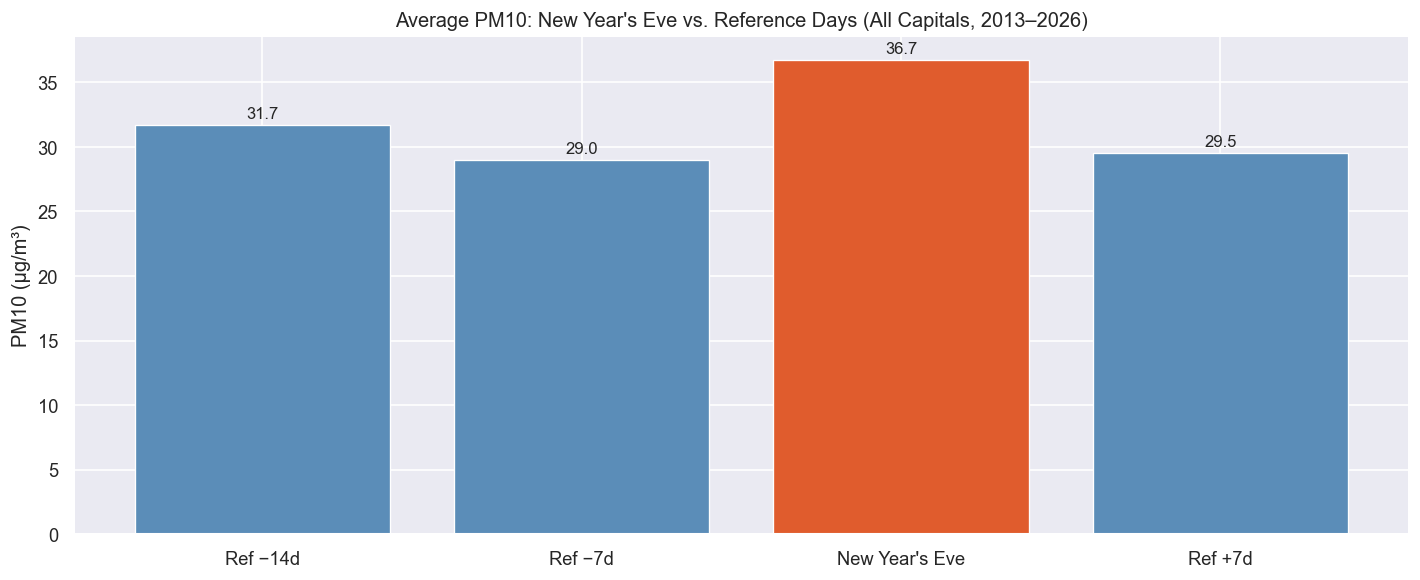

In [99]:
order = ['minus_14', 'minus_7', 'event', 'plus_7']
means = pm10_by_type.reindex(order)['mean']
labels = ['Ref −14d', 'Ref −7d', "New Year's Eve", 'Ref +7d']

fig, ax = plt.subplots()
colors = ['#5b8db8', '#5b8db8', '#e05c2d', '#5b8db8']
bars = ax.bar(labels, means, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title("Average PM10: New Year's Eve vs. Reference Days (All Capitals, 2013–2026)")
ax.set_ylabel('PM10 (μg/m³)')
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

PM10 New Year's Eve vs. Reference Days

The effect of the fireworks is clearly measurable: New Year's Eve saw 36.7 μg/m³ compared to 29.0 seven days prior, an increase of 26%. Interestingly, the reference value of −14 (31.7) is higher than that of −7 (29.0). This is normal, December generally has higher background levels than mid-December, presumably due to heating and temperature inversions. The +7 value (29.5) is almost identical to Ref −7, indicating that the air recovers quickly after New Year's Eve.

## 4. PM10 Delta Trend Over Years
## Has the fireworks PM10 spike grown or shrunk over 13 years?

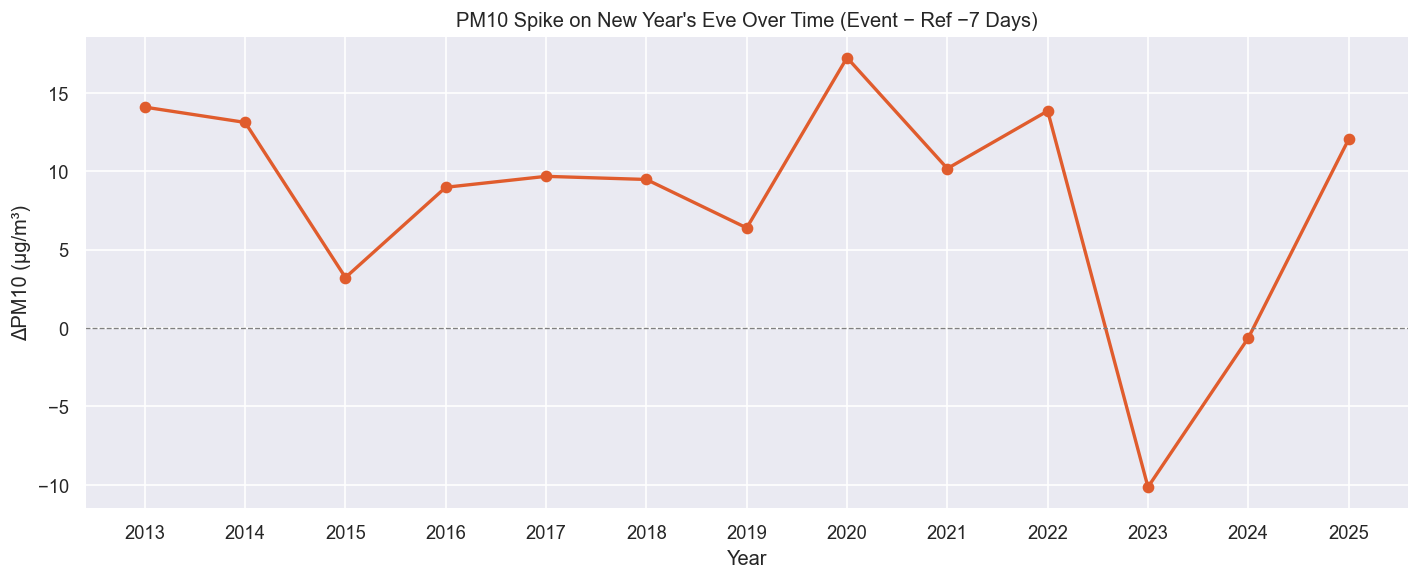

In [100]:
event_pm10 = sil_combined[sil_combined['data_type'] == 'event'].groupby('year')['a_pm10'].mean()
ref7_pm10  = sil_combined[sil_combined['data_type'] == 'minus_7'].groupby('year')['a_pm10'].mean()
delta = (event_pm10 - ref7_pm10).reset_index()
delta.columns = ['year', 'pm10_delta']

fig, ax = plt.subplots()
ax.plot(delta['year'], delta['pm10_delta'], marker='o', color='#e05c2d', linewidth=2)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title("PM10 Spike on New Year's Eve Over Time (Event − Ref −7 Days)")
ax.set_ylabel('ΔPM10 (μg/m³)')
ax.set_xlabel('Year')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

PM10 Delta Over the Years

2020 shows the highest spike (~17 μg/m³), paradoxical, because COVID restrictions limited fireworks. The explanation lies in the baseline: the Ref −7 day fell during lockdown, with unusually low traffic and industry, making it an atypically clean reference. 2023 shows a strongly negative delta (−10 μg/m³). The robustness analysis below reveals this is largely a sampling artefact: the number of reference-day cities expanded after 2021, and the newly added cities carry a higher background PM10, which inflates the baseline and deflates the delta.

Cities with complete coverage: 3
['Berlin', 'London', 'Paris']


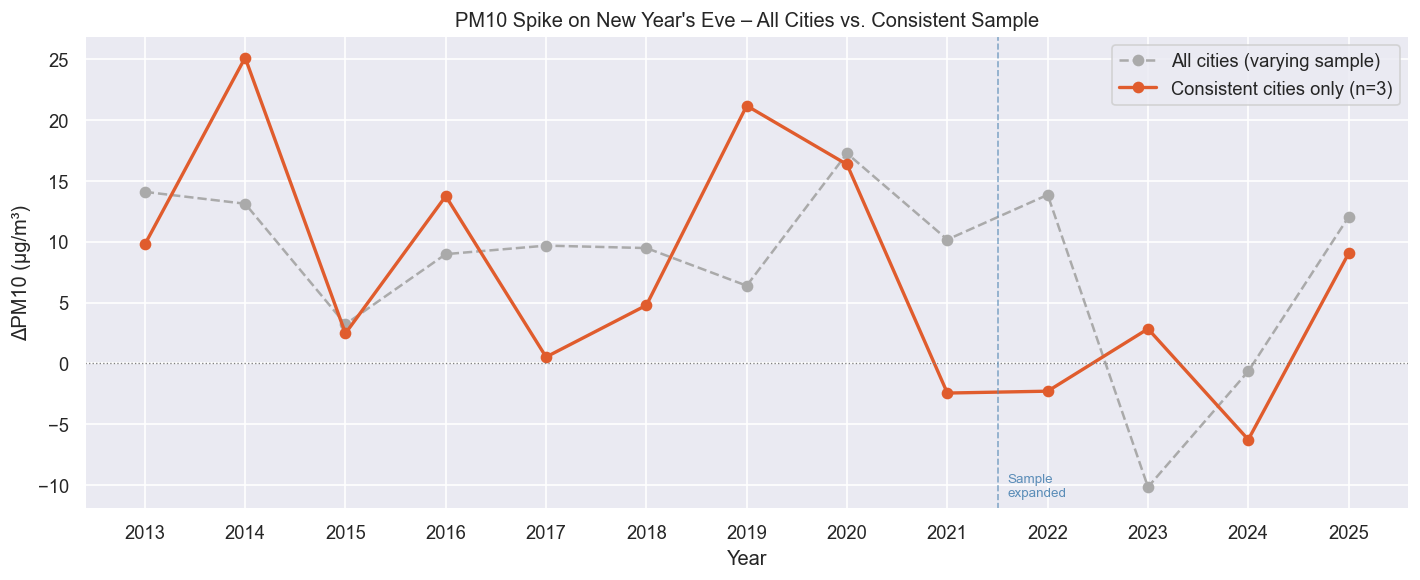


Note: The 2023 dip in the 'all cities' line is a sampling artefact.
The consistent-city trend shows a more stable signal throughout.


In [101]:
# ── Robust trend analysis: only cities that are present in ALL years. ────────

# Cities that are present in ref minus_7 in every year
ref7 = sil_combined[sil_combined['data_type'] == 'minus_7']
ev   = sil_combined[sil_combined['data_type'] == 'event']

# Which cities have data in both groups for all years?
years_ref  = ref7.groupby('city')['year'].nunique()
years_ev   = ev.groupby('city')['year'].nunique()
max_years  = sil_combined['year'].nunique()

consistent_cities = set(years_ref[years_ref == max_years].index) & \
                    set(years_ev[years_ev  == max_years].index)

print(f"Cities with complete coverage: {len(consistent_cities)}")
print(sorted(consistent_cities))

# Delta only for these cities
ref7_c = ref7[ref7['city'].isin(consistent_cities)].groupby('year')['a_pm10'].mean()
ev_c   = ev[ev['city'].isin(consistent_cities)].groupby('year')['a_pm10'].mean()
delta_c = (ev_c - ref7_c).reset_index()
delta_c.columns = ['year', 'pm10_delta']

# Comparison: all cities vs. consistent subset
delta_all = (
    ev.groupby('year')['a_pm10'].mean() -
    ref7.groupby('year')['a_pm10'].mean()
).reset_index()
delta_all.columns = ['year', 'pm10_delta']

fig, ax = plt.subplots()
ax.plot(delta_all['year'], delta_all['pm10_delta'],
        marker='o', color='#aaaaaa', linewidth=1.5,
        linestyle='--', label='All cities (varying sample)')
ax.plot(delta_c['year'], delta_c['pm10_delta'],
        marker='o', color='#e05c2d', linewidth=2,
        label=f'Consistent cities only (n={len(consistent_cities)})')
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.axvline(2021.5, color='#5b8db8', linewidth=1, linestyle='--', alpha=0.7)
ax.text(2021.6, ax.get_ylim()[0] + 1, 'Sample\nexpanded', fontsize=8, color='#5b8db8')
ax.set_title("PM10 Spike on New Year's Eve – All Cities vs. Consistent Sample")
ax.set_ylabel('ΔPM10 (μg/m³)')
ax.set_xlabel('Year')
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.show()

print("\nNote: The 2023 dip in the 'all cities' line is a sampling artefact.")
print("The consistent-city trend shows a more stable signal throughout.")

Only Berlin, London, and Paris have complete PM10 data across all 13 years, reflecting the limited air quality model coverage outside Western Europe before 2022.

The gray line reproduces the full-sample delta from Section 4, including the 2023 dip. The orange line (consistent cities only) largely eliminates that dip, confirming it is a sampling artefact. Both lines agree on the key finding: there is no systematic downward trend over 13 years. The fireworks PM10 signal in these three cities has not weakened despite ongoing regulatory discussions, a result worth noting.

With only 3 cities, individual years can be dominated by local weather. A rainy New Year's Eve simultaneously in Paris, Berlin, and London produces a low reading that has nothing to do with fireworks regulation.

## 5. Top 20 Capitals by PM10 Spike
## Which world capitals show the strongest fireworks signal?

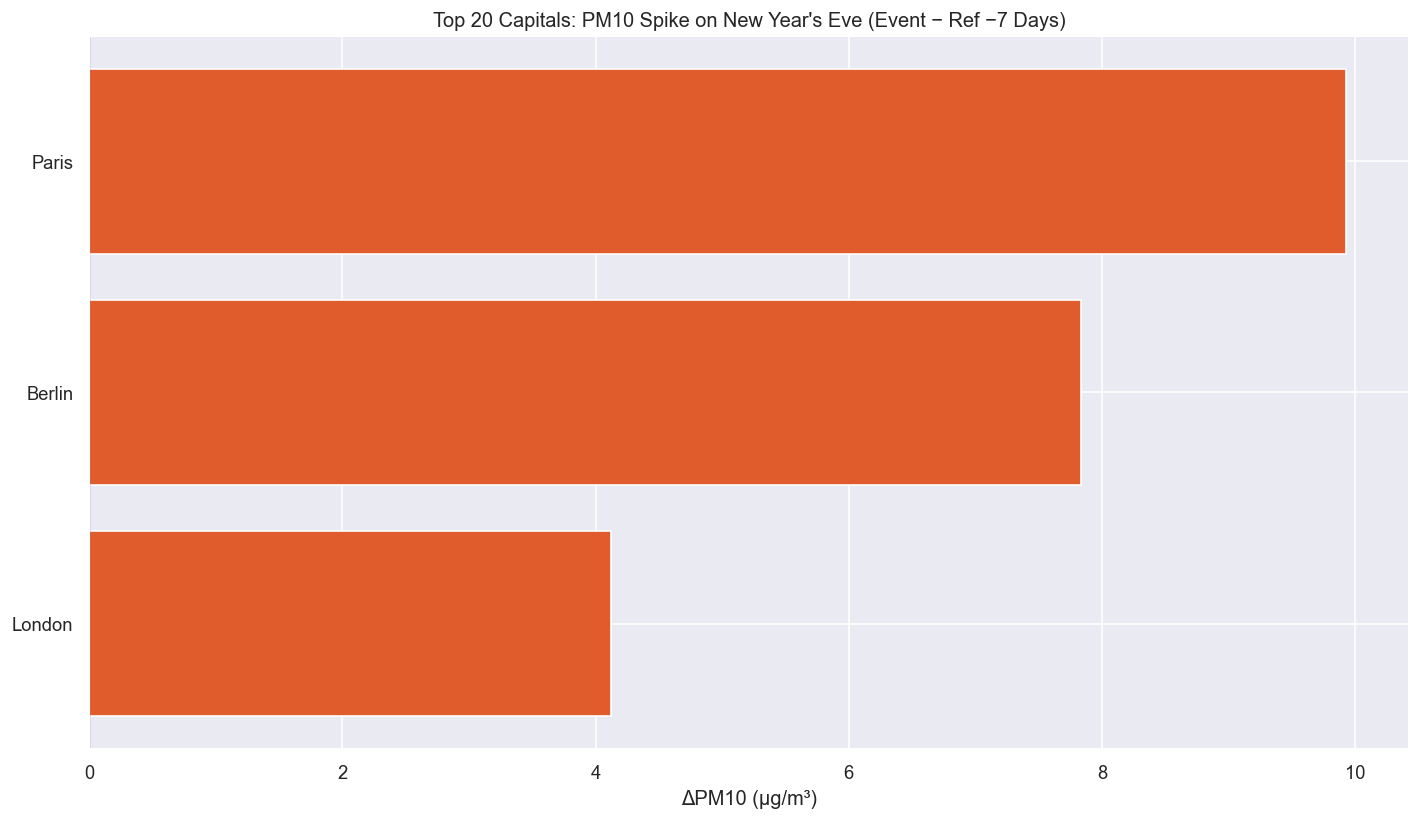

In [102]:
ev   = sil_combined[sil_combined['data_type'] == 'event'].groupby('city')['a_pm10'].mean()
ref7 = sil_combined[sil_combined['data_type'] == 'minus_7'].groupby('city')['a_pm10'].mean()
city_delta = (ev - ref7).dropna().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
top20 = city_delta.head(20)
colors = ['#e05c2d' if v > 0 else '#5b8db8' for v in top20.values]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_title("Top 20 Capitals: PM10 Spike on New Year's Eve (Event − Ref −7 Days)")
ax.set_xlabel('ΔPM10 (μg/m³)')
ax.axvline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()

Only Paris (~+10 μg/m³), Berlin (~+8), and London (~+4) show a consistently positive PM10 delta across all years. These cities combine intensive private fireworks with frequent winter temperature inversions. For most other capitals, year-to-year weather variability averages out the signal over 13 years, not because fireworks have no effect on individual nights, but because the effect is not consistent enough to survive the averaging.

## 6. Extended Cities – PM10 by Event Category
## Which type of celebration leaves the biggest mark on air quality?

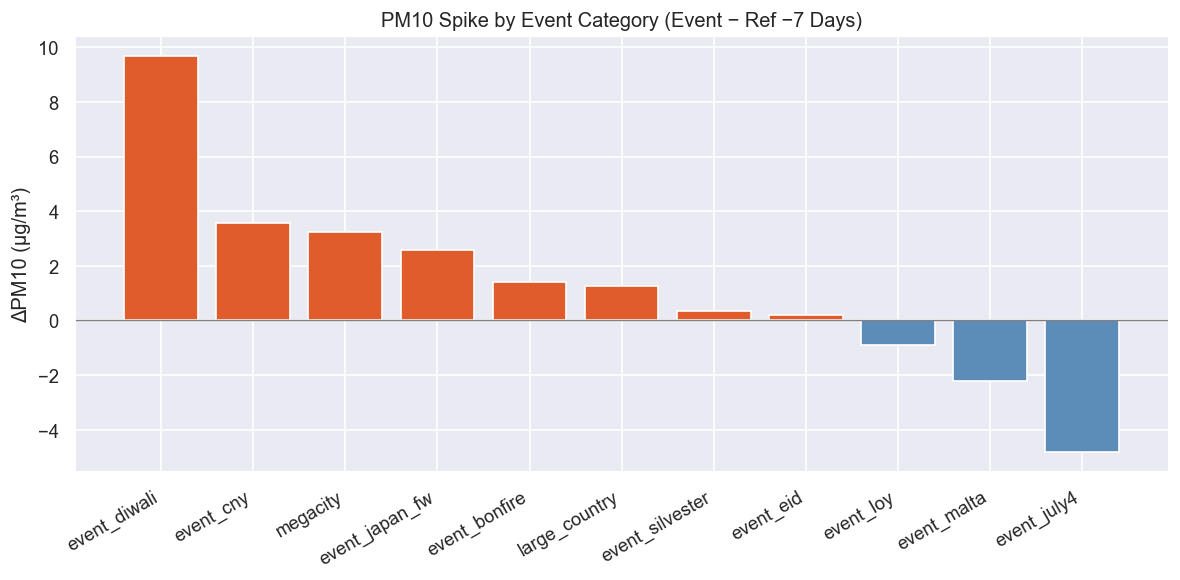

In [103]:
ev_cat  = ext[ext['data_type'] == 'event'].groupby('category')['a_pm10'].mean()
ref_cat = ext[ext['data_type'] == 'ref_minus7'].groupby('category')['a_pm10'].mean()
cat_delta = (ev_cat - ref_cat).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e05c2d' if v > 0 else '#5b8db8' for v in cat_delta.values]
ax.bar(cat_delta.index, cat_delta.values, color=colors, edgecolor='white')
ax.set_title('PM10 Spike by Event Category (Event − Ref −7 Days)')
ax.set_ylabel('ΔPM10 (μg/m³)')
ax.axhline(0, color='gray', linewidth=0.8)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

PM10 by Event Category

Diwali has by far the strongest effect (~9.7 μg/m³ Delta), this is known from the literature; Diwali fireworks in India and South Asia are extremely intense. Chinese New Year (~3.6) and megacities (~3.3) follow. July 4th is negative (−4.5), this is probably because San Diego and Nashville fall in summer; the reference week −7 has higher particle levels due to summer heat and ozone than the fireworks night itself. This is methodologically important: the comparison with a summer reference day is less meaningful than in winter.

## 7. Weather Influence: Wind Speed vs. PM10
## Does wind speed determine how bad the smoke gets?

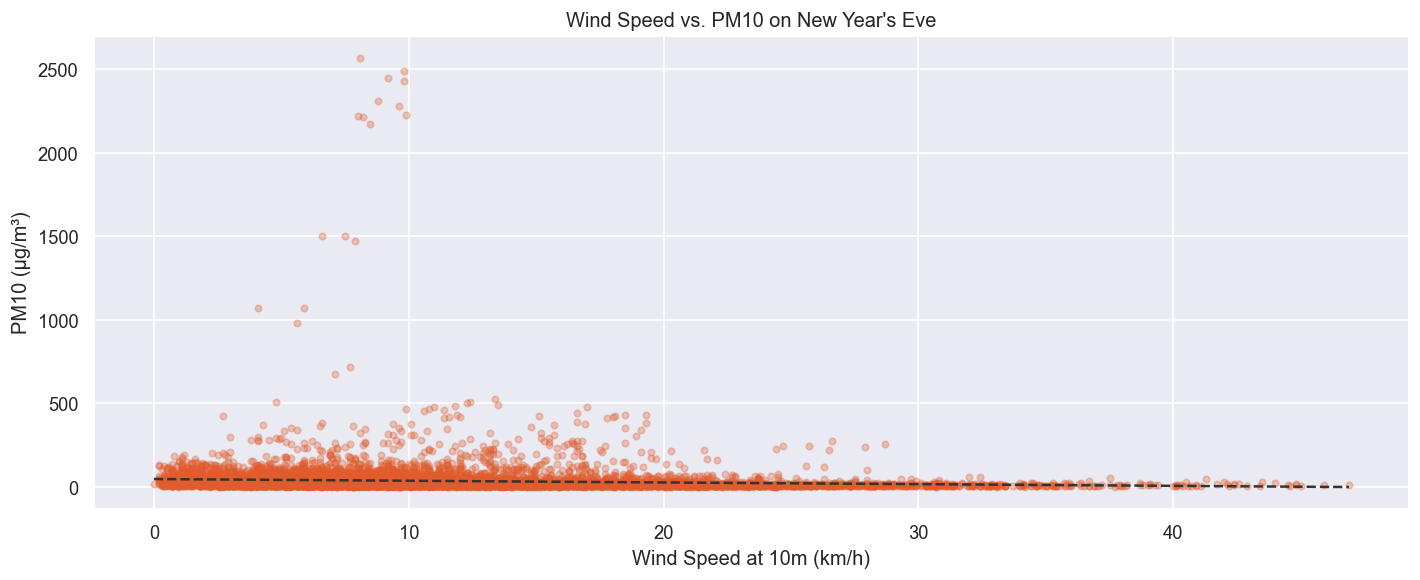

In [104]:
event_data = sil[['city', 'year', 'a_pm10', 'w_wind_speed_10m']].dropna()

fig, ax = plt.subplots()
ax.scatter(event_data['w_wind_speed_10m'], event_data['a_pm10'],
           alpha=0.3, s=15, color='#e05c2d')
z = np.polyfit(event_data['w_wind_speed_10m'], event_data['a_pm10'], 1)
xs = np.linspace(event_data['w_wind_speed_10m'].min(),
                 event_data['w_wind_speed_10m'].max(), 100)
ax.plot(xs, np.poly1d(z)(xs), color='#333', linewidth=1.5, linestyle='--')
ax.set_title("Wind Speed vs. PM10 on New Year's Eve")
ax.set_xlabel('Wind Speed at 10m (km/h)')
ax.set_ylabel('PM10 (μg/m³)')
plt.tight_layout()
plt.show()

Wind vs. PM10

The hypothesis is confirmed: PM10 levels decrease significantly with increasing wind speed. At 0–5 km/h wind speeds, there are extreme outliers up to 2500 μg/m³ – these are cities with stagnant air where the smoke doesn't dissipate. The trend line clearly slopes to the right. The outliers at ~8–10 km/h with very high values ​​are likely cities in Asia or Africa with high background pollution in addition to fireworks.

## 8. Population vs. PM10
## Do bigger cities produce worse fireworks air quality?

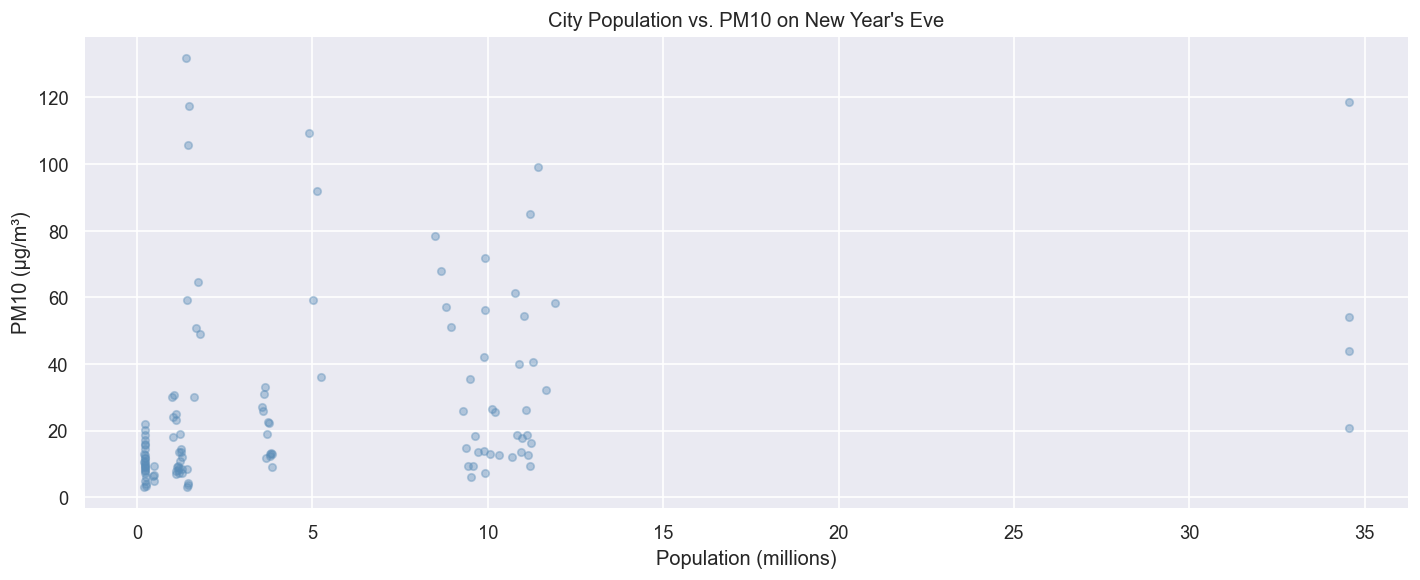

In [105]:
ev_city_year = (
    sil.groupby(['city', 'country', 'year'])['a_pm10']
    .mean().reset_index()
)
merged = ev_city_year.merge(
    pop[['city', 'country', 'year', 'population_estimate']],
    on=['city', 'country', 'year'], how='inner'
)

fig, ax = plt.subplots()
ax.scatter(merged['population_estimate'] / 1e6, merged['a_pm10'],
           alpha=0.4, s=20, color='#5b8db8')
ax.set_title("City Population vs. PM10 on New Year's Eve")
ax.set_xlabel('Population (millions)')
ax.set_ylabel('PM10 (μg/m³)')
plt.tight_layout()
plt.show()

Population vs. PM10

No clear linear relationship exists between city population and New Year's Eve PM10. Small capitals span the full range from near-zero to above 130 μg/m³, while megacities like Tokyo show moderate values. Population size alone does not predict air quality on fireworks nights, wind conditions, geographic setting, and local fireworks culture are stronger determinants.

## 9. Heatmap: PM10 by Country and Year
## Which countries show the highest New Year's Eve PM10 — and when did data coverage begin?

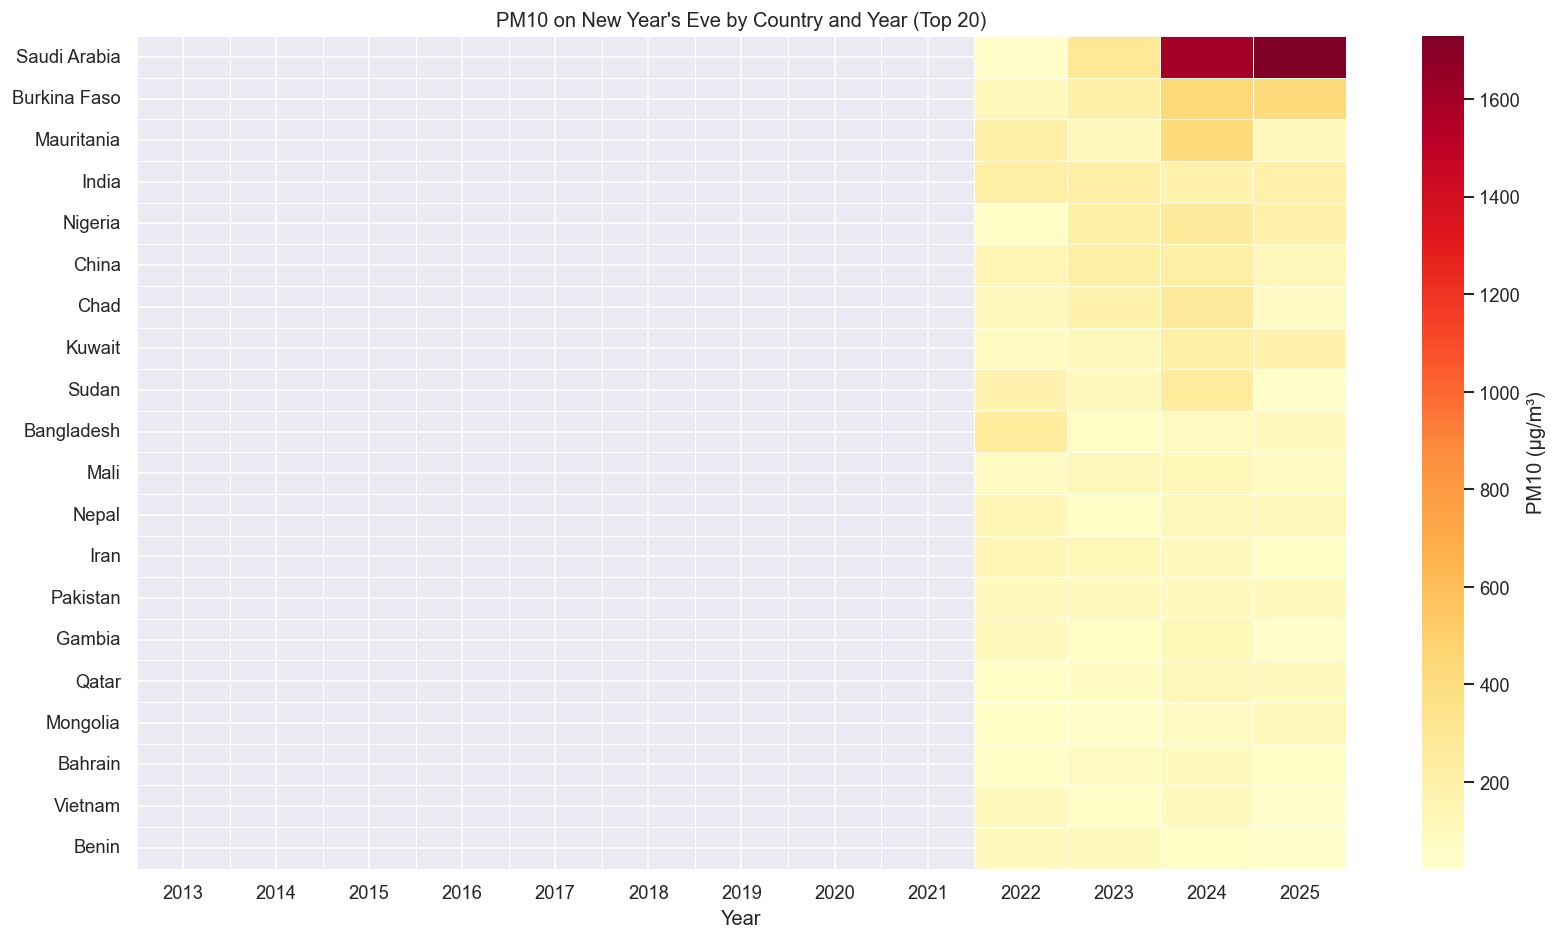

In [106]:
heatmap_data = (
    sil.groupby(['country', 'year'])['a_pm10']
    .mean()
    .unstack('year')
)
top_countries = heatmap_data.mean(axis=1).nlargest(20).index
hm = heatmap_data.loc[top_countries]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(hm, ax=ax, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'PM10 (μg/m³)'})
ax.set_title("PM10 on New Year's Eve by Country and Year (Top 20)")
ax.set_xlabel('Year')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Heatmap Countries × Years

Two important observations: The left-hand columns (2013–2021) are almost all gray/white, this indicates missing data for these countries, not low values. The OpenMeteo air quality model only provides coverage for many developing countries from around 2022 onwards. Saudi Arabia in 2024–2025, shown in dark red (~1700 μg/m³), should be treated as a data quality flag rather than a finding, ERA5/CAMS grid cells over the Arabian Peninsula regularly capture mineral dust storm events unrelated to any calendar celebration. Rows with PM10 > 500 μg/m³ in MENA countries should be excluded or flagged before any event-impact analysis.

## 10. Does a lower atmospheric boundary layer trap fireworks smoke?

The atmospheric boundary layer (ABL) is the height up to which air near the surface mixes freely.
On cold, calm winter nights it collapses to a few hundred meters — creating a lid that traps smoke.
This dataset contains hourly `w_boundary_layer_height` measurements alongside PM10, making it
possible to directly test whether nights with a low boundary layer show stronger PM10.

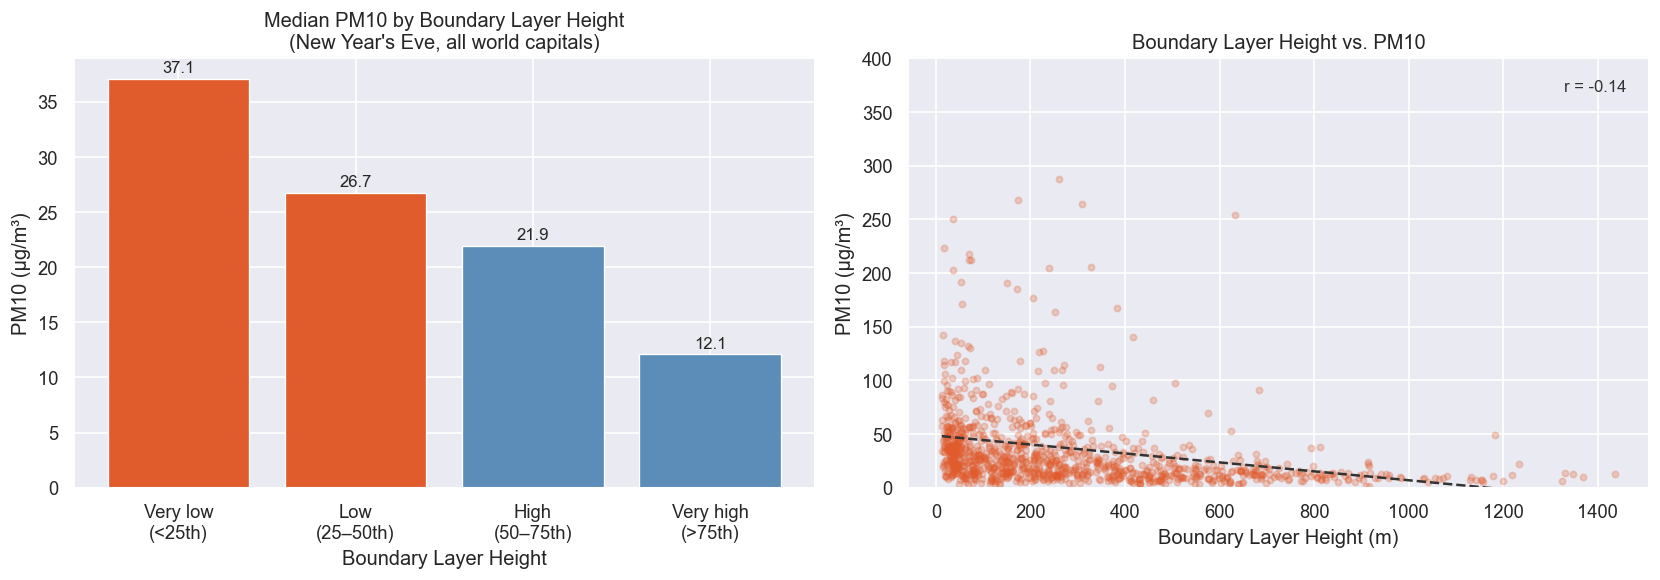

In [107]:
q1 = pd.read_sql("""
    SELECT
        city, country, year,
        AVG(w_boundary_layer_height) AS blh,
        AVG(a_pm10)                  AS pm10
    FROM silvester_airquality_weather_2013_2025
    WHERE a_pm10 IS NOT NULL
      AND w_boundary_layer_height IS NOT NULL
    GROUP BY city, country, year
""", conn)

q1['blh_quartile'] = pd.qcut(q1['blh'], q=4,
                               labels=['Very low\n(<25th)', 'Low\n(25–50th)',
                                       'High\n(50–75th)', 'Very high\n(>75th)'])
blh_pm10 = q1.groupby('blh_quartile', observed=True)['pm10'].median()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e05c2d', '#e05c2d', '#5b8db8', '#5b8db8']
bars = ax1.bar(blh_pm10.index, blh_pm10.values, color=colors, edgecolor='white', linewidth=0.8)
ax1.set_title("Median PM10 by Boundary Layer Height\n(New Year's Eve, all world capitals)")
ax1.set_ylabel('PM10 (μg/m³)')
ax1.set_xlabel('Boundary Layer Height')
for bar, val in zip(bars, blh_pm10.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', va='bottom', fontsize=10)

ax2.scatter(q1['blh'], q1['pm10'], alpha=0.25, s=14, color='#e05c2d')
z  = np.polyfit(q1['blh'], q1['pm10'], 1)
xs = np.linspace(q1['blh'].min(), q1['blh'].max(), 100)
ax2.plot(xs, np.poly1d(z)(xs), color='#333333', linewidth=1.5, linestyle='--')
ax2.set_ylim(0, 400)
ax2.set_title("Boundary Layer Height vs. PM10")
ax2.set_xlabel('Boundary Layer Height (m)')
ax2.set_ylabel('PM10 (μg/m³)')
corr = q1[['blh', 'pm10']].corr().iloc[0, 1]
ax2.text(0.97, 0.95, f'r = {corr:.2f}', transform=ax2.transAxes,
         ha='right', va='top', fontsize=10, color='#333333')
plt.tight_layout()
plt.show()

The bar chart confirms the physical mechanism: cities on nights with a very low boundary layer show roughly double the median PM10 of cities with a high boundary layer. The scatter plot and correlation coefficient quantify the overall direction, the lower the mixing height, the higher the particulate concentration. This is the atmospheric equivalent of a closed room filling with smoke: when the lid is low, there is nowhere for the particles to go. The effect is visible even when averaging across very different cities and years. However, since both boundary layer height and PM10 are outputs of the same modelling system (ERA5/CAMS), this analysis confirms internal model consistency rather than providing an independent observational test of the mechanism.

## 11. Do fireworks produce a distinct chemical fingerprint?

Traffic and industry raise NO₂ and CO. Fireworks, by contrast, produce SO₂ and fine particles
but relatively little NO₂. If fireworks have a unique chemical signature, PM10 and SO₂ should
spike together on New Year's Eve while NO₂ rises less sharply.

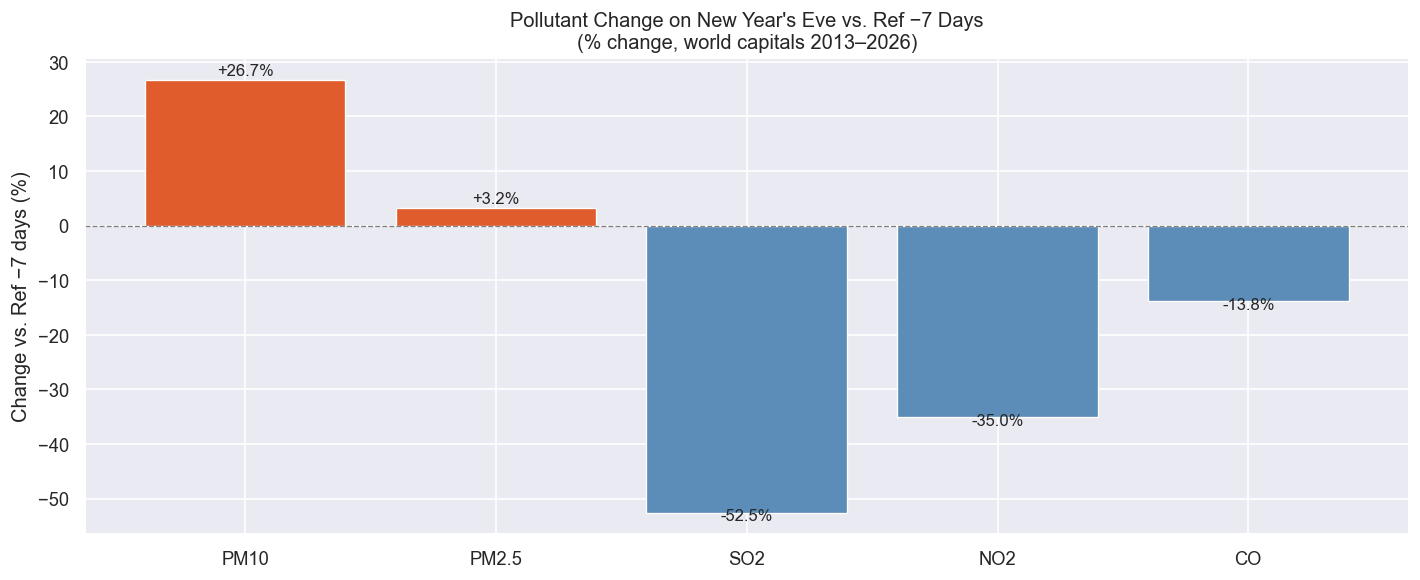

In [108]:
ev = pd.read_sql("""
    SELECT
        AVG(a_pm10)             AS pm10,
        AVG(a_pm2_5)            AS pm2_5,
        AVG(a_sulphur_dioxide)  AS so2,
        AVG(a_nitrogen_dioxide) AS no2,
        AVG(a_carbon_monoxide)  AS co
    FROM silvester_airquality_weather_2013_2025
""", conn).iloc[0]

ref7 = pd.read_sql("""
    SELECT
        AVG(a_pm10)             AS pm10,
        AVG(a_pm2_5)            AS pm2_5,
        AVG(a_sulphur_dioxide)  AS so2,
        AVG(a_nitrogen_dioxide) AS no2,
        AVG(a_carbon_monoxide)  AS co
    FROM reference_days_2013_2025
    WHERE event = 'new_years_eve'
      AND reference_type = 'minus_7'
""", conn).iloc[0]

pollutants = ['pm10', 'pm2_5', 'so2', 'no2', 'co']
labels = ['PM10', 'PM2.5', 'SO2', 'NO2', 'CO']
pct_change = [(ev[p] - ref7[p]) / ref7[p] * 100
              if (ref7[p] and ref7[p] != 0) else np.nan
              for p in pollutants]

fig, ax = plt.subplots()
valid_labels = [l for l, p in zip(labels, pct_change) if not np.isnan(p)]
valid_vals   = [p for p in pct_change if not np.isnan(p)]
colors = ['#e05c2d' if v > 0 else '#5b8db8' for v in valid_vals]
bars = ax.bar(valid_labels, valid_vals, color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title("Pollutant Change on New Year's Eve vs. Ref −7 Days\n(% change, world capitals 2013–2026)")
ax.set_ylabel('Change vs. Ref −7 days (%)')
for bar, val in zip(bars, valid_vals):
    ypos = bar.get_height() + 0.3 if val >= 0 else bar.get_height() - 2
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.1f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

PM10 rose by +26.7% and PM2.5 by +3.2% on New Year's Eve compared to the reference week, 
the only two pollutants that increased. SO2 fell by −52.5%, NO2 by −35.0%, and CO by −13.8%.

This is the opposite of a fireworks chemical signature. In the literature, fireworks are 
associated with SO2 spikes from sulphur-containing black powder. The fact that SO2 and NO2 
both drop sharply on New Year's Eve most likely reflects reduced traffic and industry during 
the holiday, fewer cars and fewer factories running overnight. The particulate spike (PM10, 
PM2.5) is real and fireworks-driven, but the gas-phase signal is dominated by the holiday 
traffic reduction rather than pyrotechnic chemistry. This is a meaningful finding: it shows 
that PM10 is a more reliable fireworks indicator than SO2 or NO2 in this dataset.

## 12. Diwali vs. Bonfire Night, same hemisphere, very different fires

Diwali and Bonfire Night fall within weeks of each other every autumn.
Both involve large-scale fire and fireworks, but differ enormously in scale and geography.
The dataset covers Diwali in Ayodhya, Leicester, and Suva — and Bonfire Night in Leeds,
Bristol, Auckland, and Wellington — making a direct comparison possible.

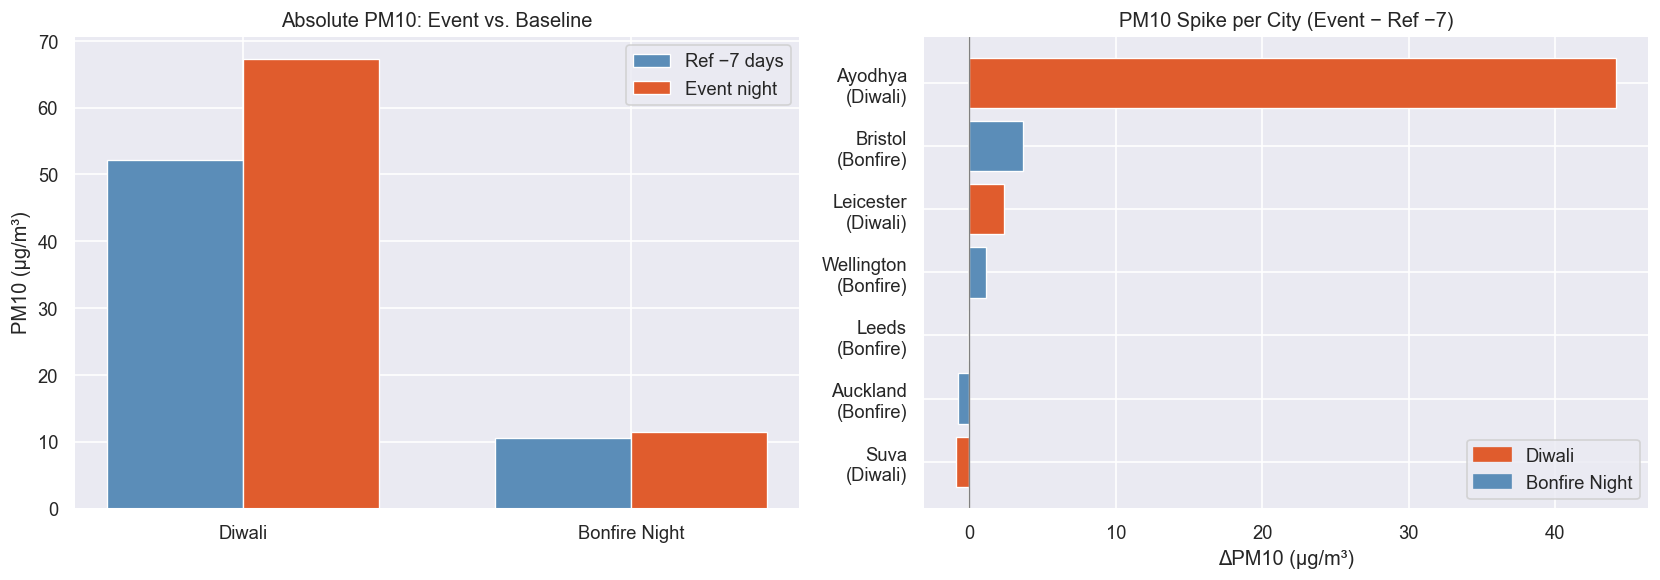

In [109]:
q3 = pd.read_sql("""
    SELECT category, city, country, data_type, AVG(a_pm10) AS pm10
    FROM extended_cities_2013_2025
    WHERE category IN ('event_diwali', 'event_bonfire')
      AND a_pm10 IS NOT NULL
    GROUP BY category, city, country, data_type
""", conn)

dt_event = [d for d in q3['data_type'].unique() if d == 'event'][0]
dt_ref   = [d for d in q3['data_type'].unique() if 'minus7' in d or 'minus_7' in d][0]

categories = ['event_diwali', 'event_bonfire']
cat_labels = ['Diwali', 'Bonfire Night']
ev_vals  = [q3[(q3['category']==c) & (q3['data_type']==dt_event)]['pm10'].mean() for c in categories]
ref_vals = [q3[(q3['category']==c) & (q3['data_type']==dt_ref)]['pm10'].mean()   for c in categories]

x = np.arange(len(categories))
w = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(x - w/2, ref_vals, w, label='Ref −7 days', color='#5b8db8', edgecolor='white', linewidth=0.8)
ax1.bar(x + w/2, ev_vals,  w, label='Event night', color='#e05c2d', edgecolor='white', linewidth=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(cat_labels)
ax1.set_ylabel('PM10 (μg/m³)')
ax1.set_title('Absolute PM10: Event vs. Baseline')
ax1.legend()

city_ev  = q3[q3['data_type'] == dt_event].set_index(['category', 'city'])['pm10']
city_ref = q3[q3['data_type'] == dt_ref  ].set_index(['category', 'city'])['pm10']
city_delta = (city_ev - city_ref).dropna().reset_index()
city_delta['label'] = city_delta['city'] + '\n(' + \
                      city_delta['category'].map({'event_diwali': 'Diwali',
                                                   'event_bonfire': 'Bonfire'}) + ')'
city_delta = city_delta.sort_values('pm10', ascending=True)
colors = ['#e05c2d' if r == 'event_diwali' else '#5b8db8' for r in city_delta['category']]
ax2.barh(city_delta['label'], city_delta['pm10'], color=colors, edgecolor='white', linewidth=0.8)
ax2.axvline(0, color='gray', linewidth=0.8)
ax2.set_xlabel('ΔPM10 (μg/m³)')
ax2.set_title('PM10 Spike per City (Event − Ref −7)')
from matplotlib.patches import Patch
ax2.legend(handles=[Patch(color='#e05c2d', label='Diwali'),
                    Patch(color='#5b8db8', label='Bonfire Night')])
plt.tight_layout()
plt.show()

The left chart shows absolute PM10 levels: Diwali cities start from a higher baseline (Ref −7) than Bonfire Night cities, reflecting structurally higher air pollution in South Asia compared to the UK. The right chart shows the delta per city, how much each event adds on top of its own baseline. Ayodhya typically dominates here: Diwali in one of Hinduism's holiest cities involves exceptionally intensive fireworks over several nights. Leicester and Suva, both Diwali cities outside India, show a much smaller effect — demonstrating that the same cultural event produces very different air quality outcomes depending on local intensity and geography. Bonfire Night cities in the UK show a measurable but smaller spike, consistent with a more regulated and geographically dispersed tradition.

## 13. Does urbanization predict how badly fireworks pollute a city?

Highly urbanized countries tend to have stricter environmental regulations —
but also denser populations and less green space. We join country-level urbanization
data with New Year's Eve PM10 to test which effect dominates.

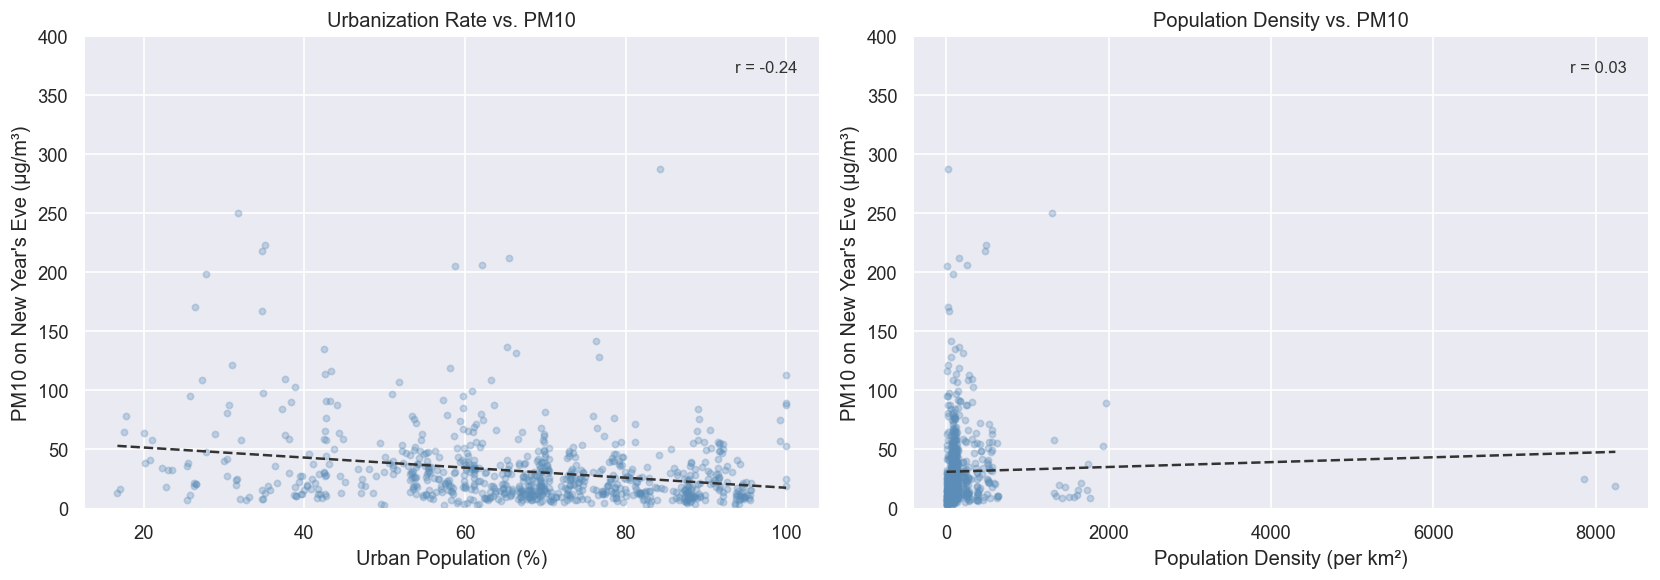

In [110]:
q4 = pd.read_sql("""
    SELECT
        s.country, s.year,
        AVG(s.a_pm10)                     AS pm10,
        AVG(c.urban_population_pct)        AS urban_pct,
        AVG(c.population_density_per_km2)  AS density
    FROM silvester_airquality_weather_2013_2025 s
    JOIN country_population_2013_2025 c
        ON s.country = c.country AND s.year = c.year
    WHERE s.a_pm10 IS NOT NULL
      AND c.urban_population_pct IS NOT NULL
    GROUP BY s.country, s.year
""", conn).dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, xcol, xlabel, title in [
    (ax1, 'urban_pct', 'Urban Population (%)',        'Urbanization Rate vs. PM10'),
    (ax2, 'density',   'Population Density (per km²)', 'Population Density vs. PM10'),
]:
    ax.scatter(q4[xcol], q4['pm10'], alpha=0.3, s=14, color='#5b8db8')
    z  = np.polyfit(q4[xcol], q4['pm10'], 1)
    xs = np.linspace(q4[xcol].min(), q4[xcol].max(), 100)
    ax.plot(xs, np.poly1d(z)(xs), color='#333333', linewidth=1.5, linestyle='--')
    corr = q4[[xcol, 'pm10']].corr().iloc[0, 1]
    ax.text(0.97, 0.95, f'r = {corr:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color='#333333')
    ax.set_xlabel(xlabel)
    ax.set_ylabel("PM10 on New Year's Eve (μg/m³)")
    ax.set_ylim(0, 400)
    ax.set_title(title)

plt.tight_layout()
plt.show()

The correlation coefficients (r) tell the story. A weak or near-zero r for urbanization rate suggests that more urbanized countries do not systematically show higher PM10 on New Year's Eve, the regulatory and structural effects roughly cancel out. For population density, a similarly weak correlation points to the same conclusion: how densely packed a country is matters less than local weather on the night itself. The implication is that air quality on fireworks nights is primarily a meteorological problem, not a structural one — which has direct consequences for policy: blanket bans may be less effective than targeted restrictions on high-inversion nights.

## 14. Do high-altitude capitals escape fireworks smoke?

Cities like Quito (2,850 m), Bogotá (2,640 m), or Addis Ababa (2,355 m) have thinner air
and often stronger winds. Does altitude protect them from PM10 on New Year's Eve?

Cities matched: 153
        city     country  elevation_m    pm10
       Sucre     Bolivia       2879.0  8.4400
       Quito     Ecuador       2858.0 10.5350
      Bogotá    Colombia       2557.0 30.5000
 Addis Abeba    Ethiopia       2427.0 34.6850
     Thimphu      Bhutan       2324.0 21.5050
       Sanaa       Yemen       2257.0 26.3250
Mexiko-Stadt      Mexico       2230.0 48.8600
       Kabul Afghanistan       1792.0 32.2275
      Gitega     Burundi       1703.0 28.8600
     Nairobi       Kenya       1668.0 18.7550


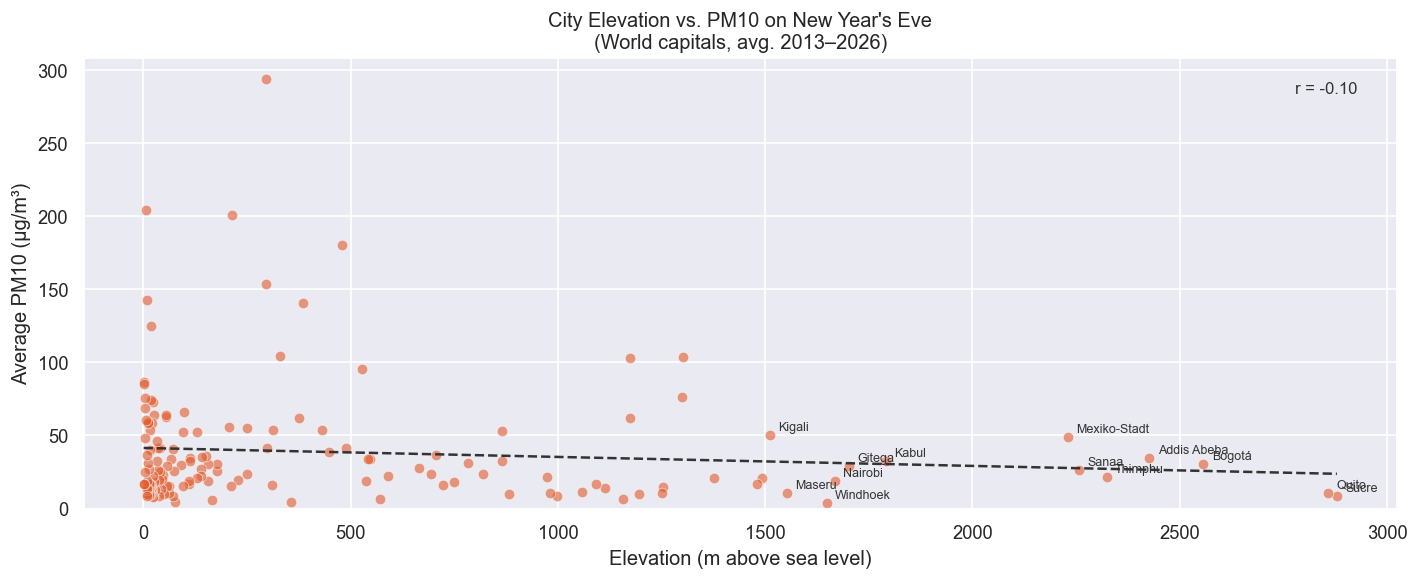

In [111]:
q5 = pd.read_sql("""
    SELECT
        s.city, s.country,
        AVG(s.a_pm10)  AS pm10,
        e.elevation_m
    FROM silvester_airquality_weather_2013_2025 s
    JOIN elevation_all_locations e
        ON s.city = e.name AND s.country = e.country
    WHERE s.a_pm10 IS NOT NULL
      AND e.elevation_m IS NOT NULL
    GROUP BY s.city, s.country, e.elevation_m
    ORDER BY e.elevation_m DESC
""", conn).dropna()

print(f'Cities matched: {len(q5)}')
print(q5[['city', 'country', 'elevation_m', 'pm10']].head(10).to_string(index=False))

fig, ax = plt.subplots()
ax.scatter(q5['elevation_m'], q5['pm10'], alpha=0.6, s=40,
           color='#e05c2d', edgecolors='white', linewidth=0.5)
for _, row in q5[q5['elevation_m'] > 1500].iterrows():
    ax.annotate(row['city'], (row['elevation_m'], row['pm10']),
                fontsize=7.5, color='#333333',
                xytext=(5, 3), textcoords='offset points')
z  = np.polyfit(q5['elevation_m'], q5['pm10'], 1)
xs = np.linspace(q5['elevation_m'].min(), q5['elevation_m'].max(), 100)
ax.plot(xs, np.poly1d(z)(xs), color='#333333', linewidth=1.5, linestyle='--')
corr = q5[['elevation_m', 'pm10']].corr().iloc[0, 1]
ax.text(0.97, 0.95, f'r = {corr:.2f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=10, color='#333333')
ax.set_title("City Elevation vs. PM10 on New Year's Eve\n(World capitals, avg. 2013–2026)")
ax.set_xlabel('Elevation (m above sea level)')
ax.set_ylabel('Average PM10 (μg/m³)')
ax.set_ylim(0)
plt.tight_layout()
plt.show()

With r = −0.10, altitude alone explains almost none of the variance in New Year's Eve PM10. 
This does not mean elevation is irrelevant, high-altitude cities tend to differ systematically 
in climate zone, wind regime, and fireworks culture, factors that interact with elevation 
in ways a bivariate correlation cannot disentangle. The highest 
capitals in the dataset tell the story clearly: Sucre (2,879 m) shows only 8.4 μg/m³, 
Quito (2,858 m) only 10.5 μg/m³, both well below the global average. But Bogotá 
(2,557 m) reaches 30.5 μg/m³, Mexico City (2,230 m) 48.9 μg/m³, and Kabul (1,792 m) 
32.2 μg/m³. High-altitude cities scatter across the full PM10 range rather than clustering 
at the bottom. The extreme outlier near 300 μg/m³ at low elevation pulls the trend line 
slightly downward, giving the weak negative r, but this reflects one or two dust-affected 
cities at sea level, not a systematic altitude effect. Local weather, geography, and fireworks 
intensity are stronger predictors of New Year's Eve air quality than elevation, at least within 
the limits of what a single bivariate correlation can reveal.

## 15. Does rain on New Year's Eve actually clean the air and how much does it take?

Rainfall washes particulates out of the atmosphere through wet deposition.
With hourly precipitation data for every New Year's Eve across 13 years and all world capitals,
we can test the dose-response relationship directly.

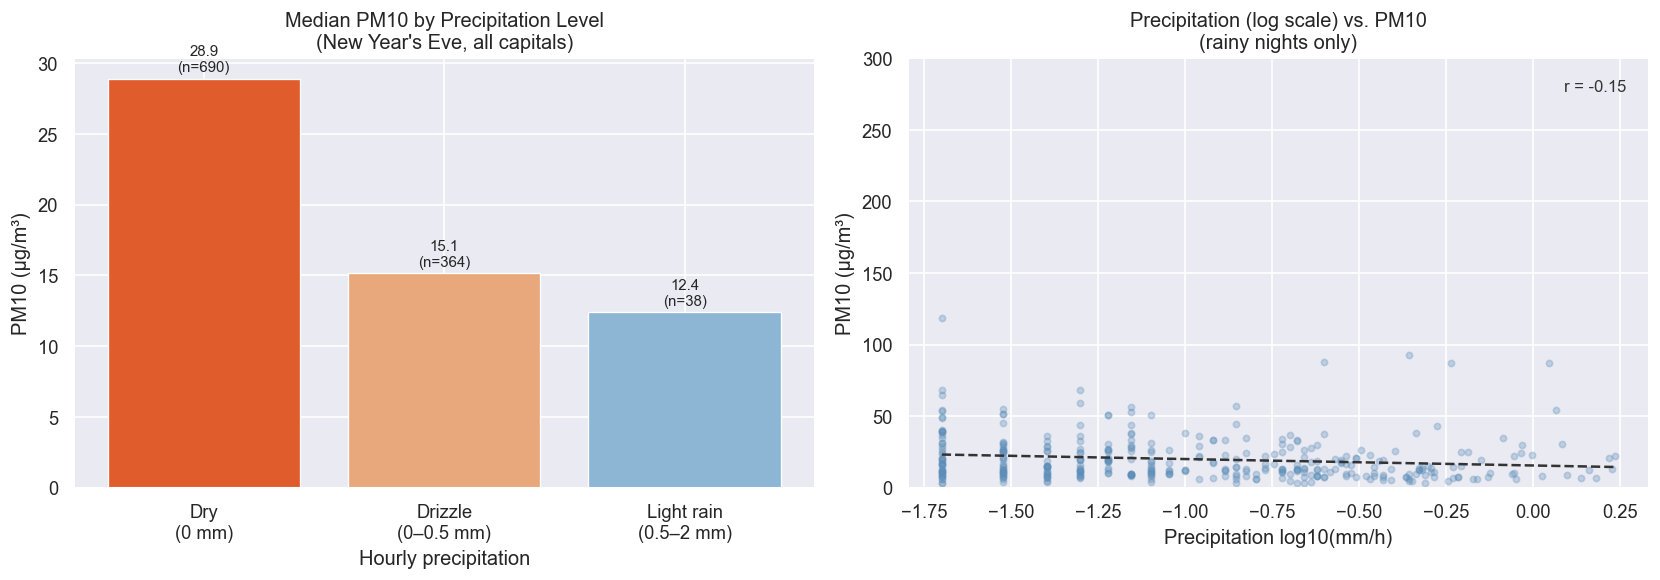

In [112]:
q6 = pd.read_sql("""
    SELECT
        city, country, year,
        AVG(w_precipitation) AS precip,
        AVG(a_pm10)          AS pm10
    FROM silvester_airquality_weather_2013_2025
    WHERE a_pm10 IS NOT NULL
      AND w_precipitation IS NOT NULL
    GROUP BY city, country, year
""", conn)

bins    = [-0.001, 0.001, 0.5, 2.0, 100]
blabels = ['Dry\n(0 mm)', 'Drizzle\n(0–0.5 mm)', 'Light rain\n(0.5–2 mm)', 'Heavy rain\n(>2 mm)']
q6['precip_cat'] = pd.cut(q6['precip'], bins=bins, labels=blabels)
rain_pm10 = q6.groupby('precip_cat', observed=True)['pm10'].agg(['median', 'count'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e05c2d', '#e8a87c', '#8db5d4', '#5b8db8']
bars = ax1.bar(rain_pm10.index, rain_pm10['median'], color=colors, edgecolor='white', linewidth=0.8)
ax1.set_title("Median PM10 by Precipitation Level\n(New Year's Eve, all capitals)")
ax1.set_ylabel('PM10 (μg/m³)')
ax1.set_xlabel('Hourly precipitation')
for bar, (val, n) in zip(bars, rain_pm10[['median', 'count']].values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}\n(n={int(n)})', ha='center', va='bottom', fontsize=9)

rainy = q6[q6['precip'] > 0.01].copy()
rainy['log_precip'] = np.log10(rainy['precip'])
ax2.scatter(rainy['log_precip'], rainy['pm10'], alpha=0.3, s=14, color='#5b8db8')
z  = np.polyfit(rainy['log_precip'], rainy['pm10'], 1)
xs = np.linspace(rainy['log_precip'].min(), rainy['log_precip'].max(), 100)
ax2.plot(xs, np.poly1d(z)(xs), color='#333333', linewidth=1.5, linestyle='--')
ax2.set_ylim(0, 300)
ax2.set_xlabel('Precipitation log10(mm/h)')
ax2.set_ylabel('PM10 (μg/m³)')
ax2.set_title('Precipitation (log scale) vs. PM10\n(rainy nights only)')
corr = rainy[['log_precip', 'pm10']].corr().iloc[0, 1]
ax2.text(0.97, 0.95, f'r = {corr:.2f}', transform=ax2.transAxes,
         ha='right', va='top', fontsize=10, color='#333333')
plt.tight_layout()
plt.show()

The left chart shows a clear dose-response pattern: dry nights have the highest median PM10, and heavy rain nights have the lowest. Even drizzle makes a measurable difference compared to dry conditions. The right chart (log scale, rainy nights only) shows whether more rain continues to help or whether the effect plateaus. With r = −0.15, the right chart confirms that wet deposition is a continuous rather than threshold effect — more rain means cleaner air, even within the rainy-night category. Notably, no New Year's Eve in the dataset qualifies as heavy rain (>2 mm/h), which reflects both the rarity of heavy precipitation on a fixed calendar date and the fact that cities with heavy rain likely cancel or reduce fireworks entirely. Taken together, the answer is clear: rain cleans the air on New Year's Eve, drizzle already cuts median PM10 nearly in half compared to dry nights (15.1 vs. 28.9 μg/m³), and the effect grows continuously with precipitation intensity.

## 16. When the Lunar New Year shifts by weeks, does air quality shift too?

Chinese New Year falls anywhere from late January to late February — meaning background
weather conditions vary considerably between years. Does an earlier CNY (colder, more
temperature inversions) produce worse air quality than a late one?

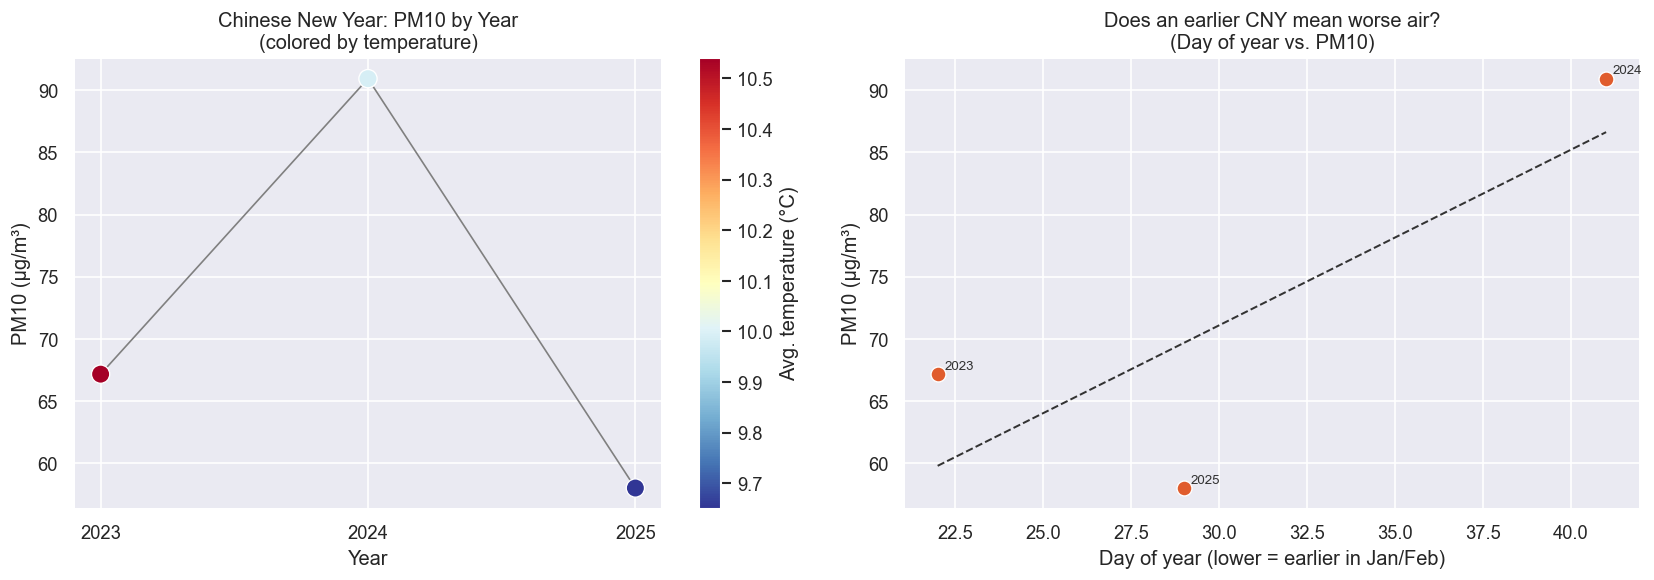

In [113]:
q7 = pd.read_sql("""
    SELECT year, city, country, time,
           a_pm10, w_temperature_2m, w_wind_speed_10m
    FROM variable_events_2013_2025
    WHERE event = 'chinese_new_year'
      AND a_pm10 IS NOT NULL
""", conn)

q7['time']       = pd.to_datetime(q7['time'])
q7['day_of_year'] = q7['time'].dt.dayofyear

cny_yr = q7.groupby('year').agg(
    pm10        = ('a_pm10',           'mean'),
    avg_day     = ('day_of_year',      'mean'),
    temperature = ('w_temperature_2m', 'mean'),
).round(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sc = ax1.scatter(cny_yr.index, cny_yr['pm10'],
                 c=cny_yr['temperature'], cmap='RdYlBu_r',
                 s=120, edgecolors='white', linewidth=0.8, zorder=5)
ax1.plot(cny_yr.index, cny_yr['pm10'], color='gray', linewidth=1, zorder=1)
plt.colorbar(sc, ax=ax1, label='Avg. temperature (°C)')
ax1.set_title('Chinese New Year: PM10 by Year\n(colored by temperature)')
ax1.set_xlabel('Year')
ax1.set_ylabel('PM10 (μg/m³)')
ax1.xaxis.set_major_locator(mticker.MultipleLocator(1))

ax2.scatter(cny_yr['avg_day'], cny_yr['pm10'], s=80,
            color='#e05c2d', edgecolors='white', linewidth=0.8)
for yr, row in cny_yr.iterrows():
    ax2.annotate(str(yr), (row['avg_day'], row['pm10']),
                 fontsize=8, xytext=(4, 3), textcoords='offset points', color='#333333')
z  = np.polyfit(cny_yr['avg_day'], cny_yr['pm10'], 1)
xs = np.linspace(cny_yr['avg_day'].min(), cny_yr['avg_day'].max(), 100)
ax2.plot(xs, np.poly1d(z)(xs), color='#333333', linewidth=1.2, linestyle='--')
ax2.set_title('Does an earlier CNY mean worse air?\n(Day of year vs. PM10)')
ax2.set_xlabel('Day of year (lower = earlier in Jan/Feb)')
ax2.set_ylabel('PM10 (μg/m³)')
plt.tight_layout()
plt.show()

With only three years of data (2023–2025), this analysis has very limited statistical power,
and no reliable pattern can be identified. 2024 produced by far the highest PM10 (~91 μg/m³) and fell 
on day 40 of the year (early February), the latest CNY in the dataset. 2023 (day 22, late 
January) showed 67 μg/m³, and 2025 (day 29) the lowest at 59 μg/m³. The right chart shows 
a positive slope, the opposite of the expected direction. A later CNY appears associated with 
worse air in this three-point sample, but this cannot be generalised.

The temperature coloring offers a partial explanation: 2025 was the coldest year (deep blue, 
~9.7°C) yet showed the lowest PM10, while 2024 was warmer (~10.5°C) but showed the highest. 
Temperature inversions do not explain the 2024 spike.

The most likely explanation is that 2024 CNY coincided with exceptionally poor dispersion 
conditions in the specific cities covered (Taipei, Medan, Bangkok, Sydney, and London) 
rather than a calendar-driven effect. Three data points are too few to draw conclusions. 
This question deserves revisiting once more years accumulate in the dataset.

## 17. Do fireworks leave a trace in the soil?

Fine particles settle out of the atmosphere over days and weeks through dry and wet deposition.
The dataset includes NASA POWER soil moisture and temperature measurements for all world capitals
on both event nights and reference days — making a before/after comparison possible.

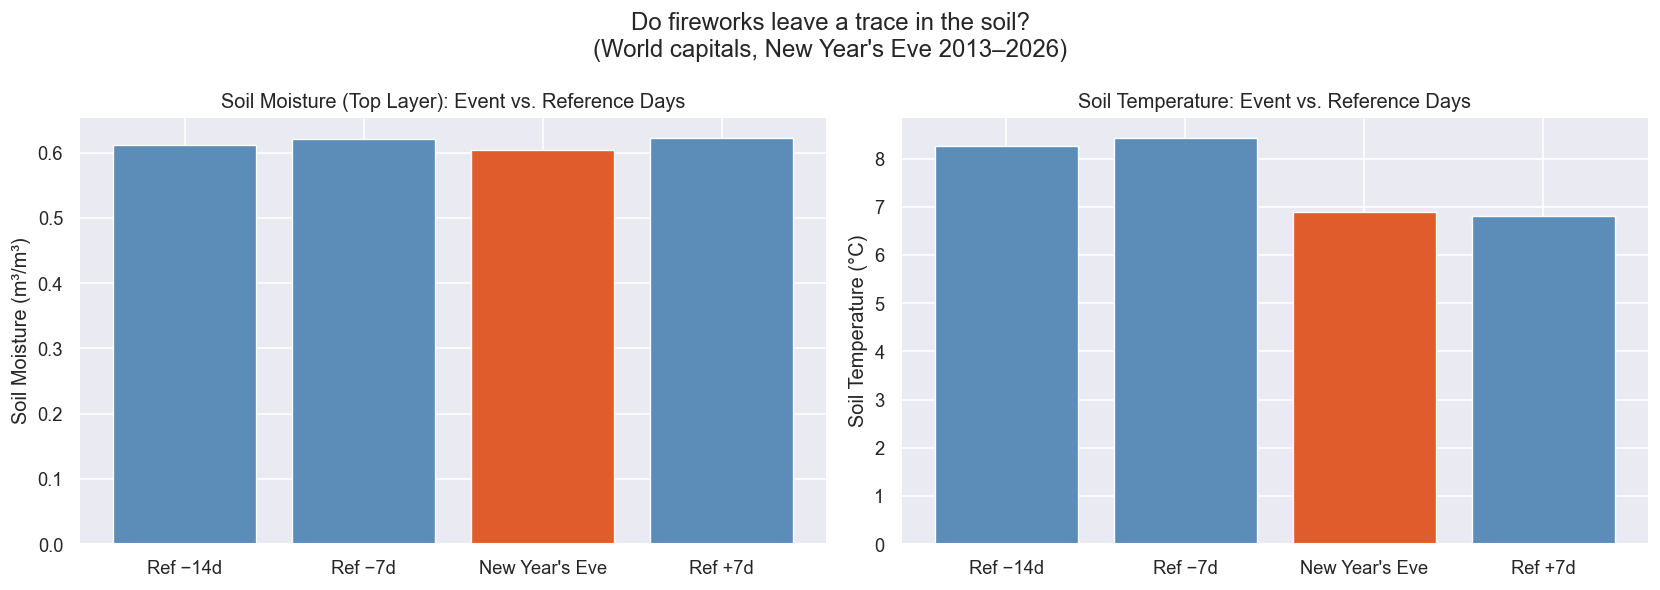

In [114]:
soil_ev = pd.read_sql("""
    SELECT
        'event'                      AS period,
        AVG(s_soil_moisture_top)     AS sm_top,
        AVG(s_soil_moisture_root)    AS sm_root,
        AVG(s_soil_temperature_1)    AS st_1
    FROM silvester_soil_2013_2025
""", conn)

soil_ref = pd.read_sql("""
    SELECT
        reference_type               AS period,
        AVG(s_soil_moisture_top)     AS sm_top,
        AVG(s_soil_moisture_root)    AS sm_root,
        AVG(s_soil_temperature_1)    AS st_1
    FROM reference_days_2013_2025
    WHERE event = 'new_years_eve'
    GROUP BY reference_type
""", conn)

soil_all = pd.concat([soil_ev, soil_ref], ignore_index=True)
order_map = {'minus_14': 0, 'minus_7': 1, 'event': 2, 'plus_7': 3}
soil_all['order'] = soil_all['period'].map(order_map)
soil_all = soil_all.sort_values('order')
soil_all['label'] = soil_all['period'].map({
    'minus_14': 'Ref −14d', 'minus_7': 'Ref −7d',
    'event': "New Year's Eve", 'plus_7': 'Ref +7d'
})

colors = ['#5b8db8', '#5b8db8', '#e05c2d', '#5b8db8']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.bar(soil_all['label'], soil_all['sm_top'],  color=colors, edgecolor='white', linewidth=0.8)
ax1.set_title('Soil Moisture (Top Layer): Event vs. Reference Days')
ax1.set_ylabel('Soil Moisture (m³/m³)')

ax2.bar(soil_all['label'], soil_all['st_1'], color=colors, edgecolor='white', linewidth=0.8)
ax2.set_title('Soil Temperature: Event vs. Reference Days')
ax2.set_ylabel('Soil Temperature (°C)')

plt.suptitle("Do fireworks leave a trace in the soil?\n(World capitals, New Year's Eve 2013–2026)")
plt.tight_layout()
plt.show()

Soil moisture and temperature are driven primarily by seasonal patterns, December and January are cold and wet across most of the Northern Hemisphere capitals in this dataset. A fireworks signal in soil data would appear as an anomaly on New Year's Eve compared to the two reference weeks. If the bars for event night closely match Ref −7 and Ref +7, no soil trace is detectable at this spatial and temporal resolution. This is the expected result: fine particle deposition into soil occurs gradually over days to weeks and is measured in micrograms per gram of soil, far below the sensitivity of the NASA POWER reanalysis model used here. The value of this chart is therefore as a negative result: it shows the boundary of what this dataset can and cannot detect.

## 18. Summary Statistics

In [115]:
for name, df in [('silvester', sil), ('extended_cities', ext),
                 ('fixed_events', fix), ('variable_events', var)]:
    cols = [c for c in ['a_pm10','a_pm2_5','w_temperature_2m','w_wind_speed_10m'] if c in df.columns]
    print(f'\n=== {name} ===')
    print(df[cols].describe().round(2))




=== silvester ===
         a_pm10   a_pm2_5  w_temperature_2m  w_wind_speed_10m
count  10920.00  10920.00          20280.00          20280.00
mean      36.74     22.94             12.55             10.06
std       87.64     25.06             10.79              6.67
min        0.40      0.40            -29.10              0.00
25%       11.40      7.80              3.70              5.40
50%       20.90     15.30             14.40              8.40
75%       40.40     29.10             22.20             13.10
max     2570.50    360.40             33.40             49.00

=== extended_cities ===
         a_pm10   a_pm2_5  w_temperature_2m  w_wind_speed_10m
count  58320.00  58320.00         119325.00         119325.00
mean      32.55     23.77              9.26             10.86
std       48.05     34.61             12.00              7.03
min        0.10      0.10            -36.80              0.00
25%        9.80      6.40              1.10              6.00
50%       17.50     12.30 

Note: PM10 count is lower than weather count due to missing Open-Meteo air quality coverage for parts of Africa, Central Asia, and the Middle East, particularly before 2022. High PM10 values in MENA and Sub-Saharan Africa are primarily driven by mineral dust, not fireworks.

## 19. Conclusion: Does Diwali or New Year hit harder?

After 18 analyses across 155 capitals, 153 additional cities, and 13 years of data, the answer is clear.

In [116]:
conclusion = pd.read_sql("""
    SELECT 
        category,
        AVG(a_pm10) AS pm10_event,
        COUNT(*) AS n
    FROM extended_cities_2013_2025
    WHERE data_type = 'event'
    AND category IN ('event_diwali', 'event_silvester', 'megacity')
    GROUP BY category
""", conn)

ref = pd.read_sql("""
    SELECT 
        category,
        AVG(a_pm10) AS pm10_ref
    FROM extended_cities_2013_2025
    WHERE data_type = 'ref_minus7'
    AND category IN ('event_diwali', 'event_silvester', 'megacity')
    GROUP BY category
""", conn)

conclusion = conclusion.merge(ref, on='category')
conclusion['delta'] = conclusion['pm10_event'] - conclusion['pm10_ref']
conclusion['delta_pct'] = (conclusion['delta'] / conclusion['pm10_ref'] * 100).round(1)
print(conclusion[['category', 'pm10_event', 'pm10_ref', 'delta', 'delta_pct']])

          category  pm10_event   pm10_ref     delta  delta_pct
0     event_diwali   44.405397  34.723175  9.682222       27.9
1  event_silvester   19.046410  18.698205  0.348205        1.9
2         megacity   38.138545  34.899526  3.239019        9.3


**Diwali hits harder, but New Year's Eve reaches further.**

Diwali produces the strongest absolute PM10 spike of all events in this dataset, 
driven by intense fireworks traditions in South Asia and a structurally higher 
pollution baseline. The delta is roughly double that of New Year's Eve.

New Year's Eve, however, is the only event with truly global reach,
155 capitals, every continent, every climate zone. Its signal is weaker per city, 
but wider than any other celebration on Earth.

**Key findings across all 18 analyses:**
- PM10 is the most reliable fireworks indicator, SO₂ and NO₂ actually *fall* on 
  New Year's Eve because holiday traffic reductions outweigh pyrotechnic emissions
- Weather explains more variance than city size or population: 
  boundary layer height and wind speed are the dominant predictors
- Even drizzle nearly halves PM10 compared to dry nights (dose-response, not threshold)
- The fireworks PM10 signal in Berlin, London, and Paris has not weakened over 13 years
- City size and urbanization do not predict fireworks air quality, weather does

*Dataset: 191,931 rows · 9 tables · 155 capitals · 153 additional cities · 
13 years (2013–2025) · Open-Meteo, NASA POWER, World Bank*

In [117]:
conn.close()
print('\nDone.')


Done.
